In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as tf

In [3]:
data = pd.read_csv("/content/breast_cancer.csv")
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
data = data.drop(['id','Unnamed: 32'],axis=1)
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
data['diagnosis'].value_counts()

B    357
M    212
Name: diagnosis, dtype: int64

In [ ]:
### B - Benign(-ve), M - Malignant(+ve)

In [8]:
import seaborn as sns

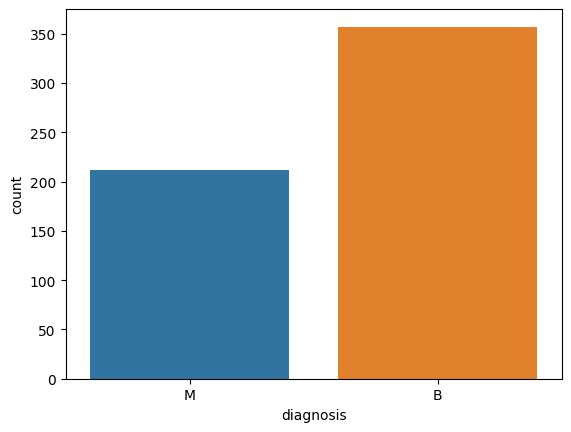

In [10]:
sns.countplot(x=data['diagnosis']);

In [12]:
### Feature Encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
data['diagnosis'] = encoder.fit_transform(data['diagnosis'])

In [13]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
y = data['diagnosis'].values
y

In [16]:
x = (data.drop(['diagnosis'],axis=1)).values
x.shape

(569, 30)

In [17]:
## normalizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [ ]:
x

In [ ]:
pd.DataFrame(x).describe()

In [22]:
### Split data into train and test

In [23]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,random_state=0,train_size=0.8)

In [24]:
### ANN Model

In [25]:
model = tf.models.Sequential()
model.add(tf.layers.Dense(16,input_dim=30,activation='relu'))  ## 16-no of neuron in hidden layer
model.add(tf.layers.Dense(32,activation='relu')) ## 2nd hidden layer
model.add(tf.layers.Dense(1,activation='sigmoid'))
## compile the model
model.compile(optimizer='adam',loss="binary_crossentropy",metrics=['accuracy'])

In [26]:
## Train the model
model.fit(xtrain,ytrain,epochs=500,validation_data=(xtest,ytest))

Epoch 1/500
15/15 [==============================] - 3s 33ms/step - loss: 0.7154 - accuracy: 0.4176 - val_loss: 0.6290 - val_accuracy: 0.5614
Epoch 2/500
15/15 [==============================] - 0s 8ms/step - loss: 0.5420 - accuracy: 0.6967 - val_loss: 0.4984 - val_accuracy: 0.7544
Epoch 3/500
15/15 [==============================] - 0s 9ms/step - loss: 0.4262 - accuracy: 0.8264 - val_loss: 0.4012 - val_accuracy: 0.8860
Epoch 4/500
15/15 [==============================] - 0s 10ms/step - loss: 0.3340 - accuracy: 0.9077 - val_loss: 0.3214 - val_accuracy: 0.9211
Epoch 5/500
15/15 [==============================] - 0s 7ms/step - loss: 0.2598 - accuracy: 0.9429 - val_loss: 0.2530 - val_accuracy: 0.9298
Epoch 6/500
15/15 [==============================] - 0s 9ms/step - loss: 0.1977 - accuracy: 0.9473 - val_loss: 0.2003 - val_accuracy: 0.9474
Epoch 7/500
15/15 [==============================] - 0s 8ms/step - loss: 0.1555 - accuracy: 0.9670 - val_loss: 0.1683 - val_accuracy: 0.9474
Epoch 8/500

In [27]:
ytest

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0])

In [ ]:
yp = model.predict(xtest)
yp = yp.round()
yp

In [30]:
from sklearn.metrics import *

In [32]:
confusion_matrix(ytest,yp)

array([[63,  4],
       [ 1, 46]])

In [33]:
accuracy_score(ytest,yp)

0.956140350877193

In [34]:
precision_score(ytest,yp)

0.92

In [35]:
recall_score(ytest,yp)

0.9787234042553191

In [36]:
f1_score(ytest,yp)

0.9484536082474226

In [ ]:
## sensitivity = no.of true positive / no of positives

In [37]:
pd.DataFrame(y).value_counts()

0    357
1    212
dtype: int64